- Title: DSC 540 Assignment for Week 9 and 10
- Author: Rethish Plappuzha Sreedharan Nair
- Date: 11-14-2025
- Description: DSC540-T301 Data Preparation (2261-1)

In [131]:
# importing necessary libraries
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import requests


# The Data Wrangling Workshop: Activity 7.01

Project Gutenberg encourages the creation and distribution of eBooks by encouraging volunteer efforts to digitize and archive cultural works. This activity aims to scrape the URL of Project Gutenberg's Top 100 eBooks to identify the eBooks' links. It uses BeautifulSoup to parse the HTML and regular expression code to identify the Top 100 eBook file numbers. You can use these numbers to download the book into your local drive if you want.

In [132]:
# Scrape Project Gutenberg Top 100 eBooks and build a DataFrame of titles and ebook links.
url = "https://www.gutenberg.org/browse/scores/top"
resp = requests.get(url, timeout=10)

In [133]:
# Function to Check the Status of the response 
def check_status(r):
    if r.status_code==200:
        print("Success!")
        return 1
    else:
        print("Failed!")
        return -1

In [134]:
# Initialize BeautifulSoup object using html parser
check_status(resp)
soup = BeautifulSoup(resp.text, "html.parser")


Success!


In [135]:
# Extract a href links using find_all function and printing the first 30 links 
links = []
for link in soup.find_all('a', href=True):
        links.append(link.get('href'))
links[0:30]

['/',
 '/donate/',
 '/about/',
 '/about/contact_information.html',
 '/about/background/',
 '/help/mobile.html',
 '/help/',
 '/ebooks/offline_catalogs.html',
 '/donate/',
 '/browse/scores/top',
 '/ebooks/categories',
 '/ebooks/bookshelf/',
 '/ebooks/',
 '/browse/scores/top',
 '/ebooks/categories',
 '/about/pretty-pictures.html',
 '#books-last1',
 '#books-last7',
 '#books-last30',
 '#authors-last1',
 '#authors-last7',
 '#authors-last30',
 '/ebooks/84',
 '/ebooks/26471',
 '/ebooks/2701',
 '/ebooks/8492',
 '/ebooks/1342',
 '/ebooks/26225',
 '/ebooks/1513',
 '/ebooks/11']

In [136]:
# Extarct file ids from the links, the books starts from the index 22
booknums = []
for a in range(22,122):
    booknums.append(int(re.findall('[0-9]+',links[a])[0])) 

In [137]:
print("\nThe file numbers for the top 100 ebooks",\
      "on Gutenberg are shown below\n"+"-"*70)
print(booknums)


The file numbers for the top 100 ebooks on Gutenberg are shown below
----------------------------------------------------------------------
[84, 26471, 2701, 8492, 1342, 26225, 1513, 11, 28942, 100, 145, 2641, 43, 37106, 20968, 67979, 2554, 16389, 768, 1260, 394, 6761, 6593, 2160, 4085, 5197, 345, 1259, 22789, 174, 22788, 98, 28054, 16328, 39635, 26296, 844, 25344, 28761, 21436, 46, 1184, 1661, 22962, 1998, 2542, 26274, 1232, 6130, 4300, 12161, 64317, 41445, 2591, 76, 36034, 45, 3207, 26460, 1400, 33944, 2600, 19506, 22452, 5200, 74, 1080, 409, 3206, 26584, 3296, 22964, 27558, 16119, 56517, 120, 77236, 41, 28947, 17199, 4363, 23079, 26297, 20973, 2148, 205, 26, 5740, 20265, 22091, 5131, 26265, 20027, 1399, 1727, 20604, 23082, 26301, 8800, 19517]


In [138]:
# Display first 2000 characters of the page text
print(soup.text[:2000])





Top 100 | Project Gutenberg





































X

Go!







 Donate 





About▼

About Project Gutenberg 
Contact Us
History & Philosophy
Kindle & eReaders
Help Pages
Offline Catalogs
Donate



Frequently Downloaded
Main Categories
Reading Lists
Search Options



Frequently Downloaded
Main Categories



Frequently Viewed or Downloaded
Calculated from the number of times each eBook gets
downloaded. (Multiple downloads from the same Internet
address on the same day count as one download. Addresses
that download more than 100 eBooks in a day are considered
robots and are not counted.)

Downloaded Books
2025-11-151729656
last 7 days10342417
last 30 days38084452

Visualizations and graphs are available as
pretty pictures.


Top 100 EBooks: Yesterday - 7 days - 30 days
Top 100 Authors: Yesterday - 7 days - 30 days

Top 100 EBooks yesterday

Frankenstein; Or, The Modern Prometheus by Mary Wollstonecraft Shelley (11415)
Spoon River Anthology by Edgar Lee Masters (3579)


In [139]:
# Finding the index of the 'Top 100 EBooks yesterday' after splitting lines from the text
lst_titles_temp=[]
start_idx=soup.text.splitlines().index('Top 100 EBooks yesterday')
print(start_idx)

101


In [140]:
# Printing the 100 Books, manipulating the proper index by adding the start_idx+2 as a constant to the iterating variable
for i in range(100):
    lst_titles_temp.append(soup.text.splitlines()[start_idx+2+i])

lst_titles_temp

['Frankenstein; Or, The Modern Prometheus by Mary Wollstonecraft Shelley (11415)',
 'Spoon River Anthology by Edgar Lee Masters (3579)',
 'Moby Dick; Or, The Whale by Herman Melville (3490)',
 'The King in Yellow by Robert W.  Chambers (2439)',
 'Pride and Prejudice by Jane Austen (2286)',
 'Fifteen Thousand Useful Phrases by Grenville Kleiser (2170)',
 'Romeo and Juliet by William Shakespeare (2158)',
 "Alice's Adventures in Wonderland by Lewis Carroll (1899)",
 'The Junior Classics, Volume 1: Fairy and wonder tales by William Allan Neilson (1862)',
 'The Complete Works of William Shakespeare by William Shakespeare (1687)',
 'Middlemarch by George Eliot (1679)',
 'A Room with a View by E. M.  Forster (1653)',
 'The Strange Case of Dr. Jekyll and Mr. Hyde by Robert Louis Stevenson (1594)',
 'Little Women; Or, Meg, Jo, Beth, and Amy by Louisa May Alcott (1537)',
 'Three Hundred Tang Poems, Volume 1 by Various (1443)',
 'The Blue Castle: a novel by L. M.  Montgomery (1407)',
 'Crime and 

In [141]:
# Using the regex to find the Name of the book and filter out the numeric parts
lst_titles=[]
for i in range(100):
    id1,id2=re.match('^[a-zA-Z ]*',lst_titles_temp[i]).span()
    lst_titles.append(lst_titles_temp[i][id1:id2])
				

In [142]:
for l in lst_titles:
    print(l)

Frankenstein
Spoon River Anthology by Edgar Lee Masters 
Moby Dick
The King in Yellow by Robert W
Pride and Prejudice by Jane Austen 
Fifteen Thousand Useful Phrases by Grenville Kleiser 
Romeo and Juliet by William Shakespeare 
Alice
The Junior Classics
The Complete Works of William Shakespeare by William Shakespeare 
Middlemarch by George Eliot 
A Room with a View by E
The Strange Case of Dr
Little Women
Three Hundred Tang Poems
The Blue Castle
Crime and Punishment by Fyodor Dostoyevsky 
The Enchanted April by Elizabeth Von Arnim 
Wuthering Heights by Emily Bront
Jane Eyre
Cranford by Elizabeth Cleghorn Gaskell 
The Adventures of Ferdinand Count Fathom 
History of Tom Jones
The Expedition of Humphry Clinker by T
The Adventures of Roderick Random by T
My Life 
Dracula by Bram Stoker 
Twenty years after by Alexandre Dumas and Auguste Maquet 
On the Duties of the Clergy by Bishop of Milan Saint Ambrose 
The Picture of Dorian Gray by Oscar Wilde 
The Federalist Papers by Alexander Hamilt

# The Data Wrangling Workshop: Activity 7.02

In [143]:
# Import urllib.request, urllib.parse, urllib.error, and json.
import json
import urllib.request
import urllib.parse
import urllib.error

In [144]:
# Load the secret API key (you have to get one from the OMDb website and use that; it has a daily limit of 1,000 API keys) 
# from a JSON file, stored in the same folder, in a variable.
json_key = json.load(open('./APIkeys.json'))
apikey = json_key['omdb_api_key']

In [145]:
serviceurl ='http://www.omdbapi.com/?'

In [146]:
def print_json(json_data) :
    list_keys = ['Title', 'Year', 'Rated', 'Released',\
                'Runtime', 'Genre', 'Director', 'Writer', \
                'Actors', 'Plot', 'Language', 'Country', \
                'Awards', 'Ratings','Metascore', 'imdbRating', \
                'imdbVotes', 'imdbID']
    print("-"*50)
    for k in list_keys:
        if k in list(json_data.keys()):
            print(f"{k}: {json_data[k]}")
            print("-"*50)

In [147]:
# Saving the poster to a directory Poster
def save_poster(json_data):
    import os
    title = json_data['Title']
    poster_url = json_data['Poster']
    """
    Splits the poster url by '.' and picks up the last string as file extension
    """
    poster_file_extension=poster_url.split('.')[-1] # Reads the image file from web    
    poster_data = urllib.request.urlopen(poster_url).read()
    savelocation=os.getcwd()+'/'+'Posters'+'/'
    """ 
    Creates new directory if the directory does not exist.Otherwise, 
    just use the existing path.
    """

    if not os.path.isdir(savelocation):
        os.mkdir(savelocation)
    filename=savelocation+str(title)+'.'+poster_file_extension
    f=open(filename,'wb')
    f.write(poster_data)
    f.close()

In [148]:
# Defining the search movie function and printing the details using the print_json method
def search_movie(title):
    try:
        url = serviceurl \
            + urllib.parse.urlencode({'t':str(title)})+'&apikey='+apikey
        print(f'Retrieving the data of "{title}" now... ')
        print(url)
        uh = urllib.request.urlopen(url)
        data = uh.read()
        json_data=json.loads(data)
        if json_data['Response']=='True':
            print_json(json_data)
            """Asks user whether to download the poster of the movie"""
            if json_data['Poster']!='N/A':
                save_poster(json_data)
            else:
                print("Error encountered: ", json_data['Error'])
    except urllib.error.URLError as e:
        print(f"ERROR: {e.reason}")

In [149]:
# Calling the function search_movie 
search_movie("Titanic")

Retrieving the data of "Titanic" now... 
http://www.omdbapi.com/?t=Titanic&apikey=35c712e6
--------------------------------------------------
Title: Titanic
--------------------------------------------------
Year: 1997
--------------------------------------------------
Rated: PG-13
--------------------------------------------------
Released: 19 Dec 1997
--------------------------------------------------
Runtime: 194 min
--------------------------------------------------
Genre: Drama, Romance
--------------------------------------------------
Director: James Cameron
--------------------------------------------------
Writer: James Cameron
--------------------------------------------------
Actors: Leonardo DiCaprio, Kate Winslet, Billy Zane
--------------------------------------------------
Plot: A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic.
--------------------------------------------------
Language: English, Swe

# Connect to an API of your choice and do a simple data pull - you can use any API - except the API you have selected for your project.

In [150]:
def get_random_joke():
    """
    Fetch a random joke from the Official Joke API and print it.
    Returns the parsed JSON dict on success, or None on failure.
    """
    api_url = "https://official-joke-api.appspot.com/random_joke"
    try:
        resp = requests.get(api_url, timeout=5)
        resp.raise_for_status()
        joke = resp.json()
        setup = joke.get("setup", "")
        punchline = joke.get("punchline", "")
        print("Setup:", setup)
        print("Punchline:", punchline)
        return joke
    except requests.RequestException as e:
        print("Failed to fetch joke:", e)
        return None

In [151]:
# Calling the API 11 times
for i in range(1,11):
    print("\nJoke - {}".format((i)))
    joke_data = get_random_joke()
    


Joke - 1
Setup: Why does it take longer to get from 1st to 2nd base, than it does to get from 2nd to 3rd base?
Punchline: Because there’s a Shortstop in between!

Joke - 2
Setup: Did you hear about the hungry clock?
Punchline: It went back four seconds.

Joke - 3
Setup: Why are pirates called pirates?
Punchline: Because they arrr!

Joke - 4
Setup: The punchline often arrives before the set-up.
Punchline: Do you know the problem with UDP jokes?

Joke - 5
Setup: Why did the chicken cross the playground?
Punchline: To get to the other slide.

Joke - 6
Setup: Did you know crocodiles could grow up to 15 feet?
Punchline: But most just have 4.

Joke - 7
Setup: Why don't scientists trust atoms?
Punchline: Because they make up everything.

Joke - 8
Setup: What did one snowman say to the other snow man?
Punchline: Do you smell carrot?

Joke - 9
Setup: What’s the difference between an African elephant and an Indian elephant?
Punchline: About 5000 miles.

Joke - 10
Setup: What type of music do ba

# Visualizations
Using one of the datasets provided in Weeks 7 & 8, or a dataset of your own, choose 3 of the following visualizations to complete. You must submit via PDF along with your code if you are using PyCharm, otherwise if you submit a notebook file make sure your plots are visible in your notebook or PDF that you submit. You are free to use Matplotlib, Seaborn or another package if you prefer.

In [152]:
df_candydata = pd.read_excel('./data/CANDYDATA.xlsx')
df_candydata

/opt/miniconda3/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,ITEM,JOY,DESPAIR,NET FEELIES,NET CLOUT,DESPAIR (NEG)
0,York Peppermint Patties,634,78,556.0,1.639118,-78.0
1,Whole Wheat anything,21,419,-398.0,1.012938,-419.0
2,White Bread,15,473,-458.0,1.123440,-473.0
3,Vicodin,323,210,113.0,1.227036,-210.0
4,Twix,770,26,744.0,1.832497,-26.0
...,...,...,...,...,...,...
82,Black Jacks,34,252,-218.0,0.658410,-252.0
83,Any full-sized candy bar,828,13,815.0,1.936093,-13.0
84,Anonymous brown globs that come in black and o...,120,663,-543.0,1.802569,-663.0
85,100 Grand Bar,570,34,536.0,1.390488,-34.0


array([[<Axes: title={'center': 'JOY'}>,
        <Axes: title={'center': 'NET FEELIES'}>]], dtype=object)

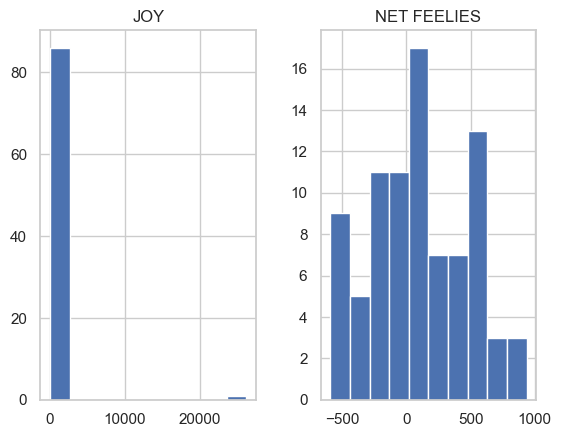

In [153]:
# Drawing a historgram of JOY and NET FEELIES
df_candydata[['JOY','NET FEELIES']].hist()

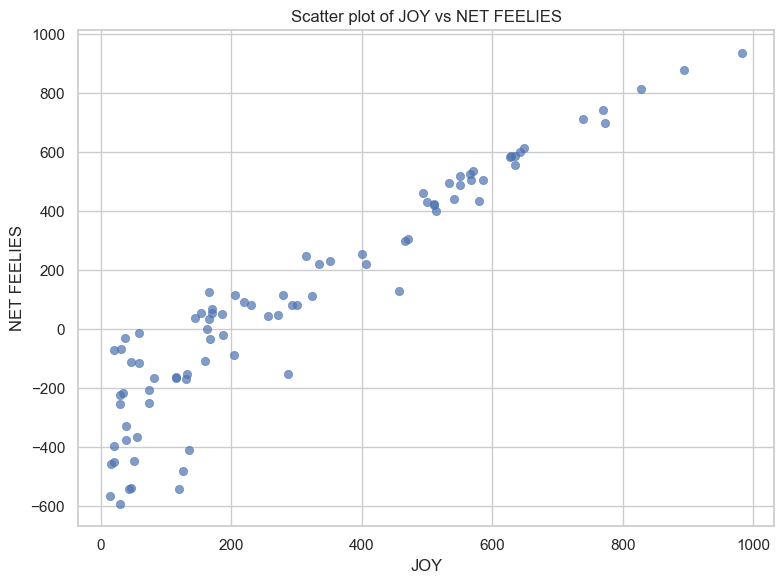

In [154]:
## Plotting a scatter plot for the JOY and FEELIES

import seaborn as sns

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Choose columns to plot; prefer JOY vs NET FEELIES if available
x = df_candydata['JOY']
y = df_candydata['NET FEELIES']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x, y=y, alpha=0.7, edgecolor=None)
plt.xlabel(x.name)
plt.ylabel(y.name)
plt.title(f"Scatter plot of {x.name} vs {y.name}")
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<Axes: title={'center': 'USA - Age and Count'}, xlabel='Q3: AGE'>

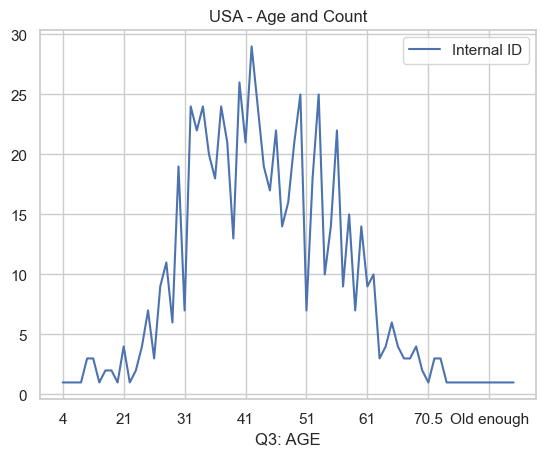

In [155]:
# Plotting the line graph
# We are using the Data from the USA Country 
# The Plot shows the How many candy consumption per age group 
df_met_objects = pd.read_excel('./data/candyhierarchy2017.xlsx')
df_usa = df_met_objects[df_met_objects['Q4: COUNTRY']=='USA']

# Creating a new data frame using the group by method. 
df_usa_age_grp = df_usa.groupby(['Q3: AGE'])['Internal ID'].count().reset_index()
df_usa_age_grp.plot(x='Q3: AGE', y='Internal ID', kind='line', title='USA - Age and Count')